# 04 — Sensitivity Analysis and the Efficient Frontier

**Author:** Shuxin Dong  
**Project:** Math 586 — Loan Approval Optimization  
**Input:**  `data/processed/loans_with_profit.csv`  (from notebook 02)  
**Output:** `outputs/sensitivity_results.csv` + figures


## Parameter grid

- Capital budgets: $0.5B, $1.0B, $1.5B, $2.0B, $2.5B (5 values)
- Portfolio PD caps: 0.15, 0.18, 0.20, 0.22, 0.25, 0.28, 0.30 (7 values)
- Total runs: 35

Each run uses a relaxed optimality gap (1%) and a 3-minute time limit per run, so the full sweep should finish in 30–60 minutes.



## 1. Imports, paths, load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp
from pathlib import Path
import time

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROFIT_PATH = PROCESSED_DIR / "loans_with_profit.csv"
RESULTS_PATH = OUTPUTS_DIR / "sensitivity_results.csv"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

df = pd.read_csv(PROFIT_PATH).reset_index(drop=True)
n = len(df)

# Pre-extract numpy arrays for speed in solver function
loan_amnt_arr = df["loan_amnt"].values
pd_cal_arr = df["pd_calibrated"].values
pi_arr = df["pi"].values
purposes_arr = df["purpose"].values
target_arr = df["target_default"].values
ead_arr = df["ead"].values
net_income_arr = df["net_income_good"].values
unique_purposes = df["purpose"].unique()

print(f"Loaded {n:,} loans across {len(unique_purposes)} purpose categories.")
print(f"PuLP version: {pulp.__version__}")

Loaded 169,321 loans across 12 purpose categories.
PuLP version: 3.3.0


## 2. Define the parameter grid

We choose 5 budget levels and 7 PD caps, giving 35 optimization runs.

In [2]:
BUDGETS = [0.5e9, 1.0e9, 1.5e9, 2.0e9, 2.5e9]                  # in dollars
PD_CAPS = [0.15, 0.18, 0.20, 0.22, 0.25, 0.28, 0.30]
PURPOSE_CAP = 0.30  # held fixed at 30% throughout the sweep

param_grid = [(b, p) for b in BUDGETS for p in PD_CAPS]
print(f"Total parameter combinations: {len(param_grid)}")
print(f"  Budgets: {[f'${b/1e9:.1f}B' for b in BUDGETS]}")
print(f"  PD caps: {PD_CAPS}")
print(f"  Purpose cap (fixed): {PURPOSE_CAP*100:.0f}%")

Total parameter combinations: 35
  Budgets: ['$0.5B', '$1.0B', '$1.5B', '$2.0B', '$2.5B']
  PD caps: [0.15, 0.18, 0.2, 0.22, 0.25, 0.28, 0.3]
  Purpose cap (fixed): 30%


## 3. Reusable build-and-solve function

Wraps the entire BIP construction + solve into one function. Returns a dict with all the metrics we need.

**Speed-ups vs notebook 03:**
- `gapRel=0.01` — accept any solution within 1% of the LP relaxation upper bound. This is standard in industry; it cuts solve time dramatically while sacrificing almost nothing in business value.
- `timeLimit=180` — hard cap of 3 minutes per run. If we hit it, we keep the best feasible solution found.
- `msg=False` — suppresses CBC's verbose output (we have 35 runs and don't need to see them all).

In [3]:
def build_and_solve(budget: float, pd_cap: float, purpose_cap: float = 0.30,
                    time_limit: int = 180, gap_rel: float = 0.01) -> dict:
    """Build the BIP for given parameters and solve it. Returns a metrics dict."""
    t0 = time.time()
    
    prob = pulp.LpProblem("LoanApproval", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(n)]
    
    # Objective
    prob += pulp.lpSum([pi_arr[i] * x[i] for i in range(n)])
    
    # Capital budget
    prob += pulp.lpSum([loan_amnt_arr[i] * x[i] for i in range(n)]) <= budget
    
    # Portfolio PD
    prob += pulp.lpSum([loan_amnt_arr[i] * (pd_cal_arr[i] - pd_cap) * x[i] for i in range(n)]) <= 0
    
    # Concentration by purpose
    for purp in unique_purposes:
        in_purp = (purposes_arr == purp)
        prob += (
            pulp.lpSum([loan_amnt_arr[i] * x[i] for i in range(n) if in_purp[i]])
            - purpose_cap * pulp.lpSum([loan_amnt_arr[i] * x[i] for i in range(n)])
        ) <= 0
    
    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=time_limit, gapRel=gap_rel)
    status = prob.solve(solver)
    solve_time = time.time() - t0
    
    decisions = np.array([int(round(x[i].value())) if x[i].value() is not None else 0
                          for i in range(n)])
    
    if decisions.sum() == 0:
        return {
            "budget": budget, "pd_cap": pd_cap, "status": pulp.LpStatus[status],
            "solve_time": solve_time, "n_approved": 0,
            "approval_rate": 0.0, "total_volume": 0.0,
            "weighted_pd": 0.0, "realized_default_rate": 0.0,
            "expected_profit": 0.0, "realized_profit": 0.0,
            "roi_expected": 0.0, "roi_realized": 0.0,
        }
    
    approved_mask = decisions == 1
    vol = loan_amnt_arr[approved_mask].sum()
    weighted_pd = (pd_cal_arr[approved_mask] * loan_amnt_arr[approved_mask]).sum() / vol
    real_def = target_arr[approved_mask].mean()
    
    realized_pl = np.where(
        target_arr[approved_mask] == 0,
        net_income_arr[approved_mask] - 200.0,
        -0.9013 * ead_arr[approved_mask] - 200.0,
    )
    realized_profit = realized_pl.sum()
    expected_profit = pi_arr[approved_mask].sum()
    
    return {
        "budget": budget,
        "pd_cap": pd_cap,
        "status": pulp.LpStatus[status],
        "solve_time": solve_time,
        "n_approved": int(decisions.sum()),
        "approval_rate": decisions.sum() / n * 100,
        "total_volume": vol,
        "weighted_pd": weighted_pd,
        "realized_default_rate": real_def * 100,
        "expected_profit": expected_profit,
        "realized_profit": realized_profit,
        "roi_expected": expected_profit / vol * 100,
        "roi_realized": realized_profit / vol * 100,
    }

print("Function defined.")

Function defined.


## 4. Warm-up run

Before running 35 jobs in a loop, let's verify the function produces sensible output for one parameter combination — and get a feel for how long a single run takes.

In [4]:
print("Warm-up run: Budget=$1.5B, PD cap=0.20")
warm = build_and_solve(budget=1.5e9, pd_cap=0.20)
for k, v in warm.items():
    if isinstance(v, float) and abs(v) > 100:
        print(f"  {k:25s} = {v:,.2f}")
    else:
        print(f"  {k:25s} = {v}")
print("\nIf realized_profit is around $90M and roi_realized is around 8.6%, the function matches notebook 03.")

Warm-up run: Budget=$1.5B, PD cap=0.20
  budget                    = 1,500,000,000.00
  pd_cap                    = 0.2
  status                    = Optimal
  solve_time                = 54.1013879776001
  n_approved                = 65023
  approval_rate             = 38.40220645991933
  total_volume              = 935,063,625.00
  weighted_pd               = 0.19999987927615634
  realized_default_rate     = 20.248219860664687
  expected_profit           = 82,116,853.59
  realized_profit           = 62,444,081.71
  roi_expected              = 8.781953590749989
  roi_realized              = 6.678056983029721

If realized_profit is around $90M and roi_realized is around 8.6%, the function matches notebook 03.


## 5. Run the full sweep

**This cell is the long one — expect 30 to 60 minutes total.** Progress will print after each run so you can see how it's tracking. If you need to interrupt and resume, the `results` list is built incrementally in memory.

In [5]:
results = []
total = len(param_grid)
t_start = time.time()

for i, (b, p) in enumerate(param_grid, start=1):
    elapsed = time.time() - t_start
    print(f"[{i:2d}/{total}]  B=${b/1e9:.1f}B  PD≤{p:.2f}  ...  (elapsed so far: {elapsed/60:.1f} min)")
    res = build_and_solve(budget=b, pd_cap=p)
    results.append(res)
    print(f"           → {res['n_approved']:>6,} loans, ROI={res['roi_realized']:.2f}%, "
          f"profit=${res['realized_profit']/1e6:.1f}M, solve={res['solve_time']:.1f}s")

total_time = time.time() - t_start
print(f"\n=== SWEEP COMPLETE ===")
print(f"Total runs:  {len(results)}")
print(f"Total time:  {total_time/60:.1f} min")
print(f"Avg per run: {total_time/len(results):.1f} sec")

[ 1/35]  B=$0.5B  PD≤0.15  ...  (elapsed so far: 0.0 min)
           → 34,729 loans, ROI=8.53%, profit=$42.7M, solve=52.5s
[ 2/35]  B=$0.5B  PD≤0.18  ...  (elapsed so far: 0.9 min)
           → 32,654 loans, ROI=9.99%, profit=$49.9M, solve=50.5s
[ 3/35]  B=$0.5B  PD≤0.20  ...  (elapsed so far: 1.7 min)
           → 31,613 loans, ROI=10.52%, profit=$52.6M, solve=54.8s
[ 4/35]  B=$0.5B  PD≤0.22  ...  (elapsed so far: 2.6 min)
           → 30,838 loans, ROI=11.10%, profit=$55.5M, solve=58.6s
[ 5/35]  B=$0.5B  PD≤0.25  ...  (elapsed so far: 3.6 min)
           → 29,785 loans, ROI=11.44%, profit=$57.2M, solve=50.5s
[ 6/35]  B=$0.5B  PD≤0.28  ...  (elapsed so far: 4.5 min)
           → 29,273 loans, ROI=11.56%, profit=$57.8M, solve=48.9s
[ 7/35]  B=$0.5B  PD≤0.30  ...  (elapsed so far: 5.3 min)
           → 29,273 loans, ROI=11.56%, profit=$57.8M, solve=48.0s
[ 8/35]  B=$1.0B  PD≤0.15  ...  (elapsed so far: 6.1 min)
           → 49,476 loans, ROI=6.52%, profit=$44.2M, solve=46.9s
[ 9/35]  B=

## 6. Tidy results into a DataFrame

In [6]:
rdf = pd.DataFrame(results)
rdf["budget_label"] = rdf["budget"].apply(lambda v: f"${v/1e9:.1f}B")

# Quick view
print("Sweep results (selected columns):")
print(rdf[["budget_label", "pd_cap", "n_approved", "approval_rate",
           "weighted_pd", "realized_default_rate",
           "realized_profit", "roi_realized"]].round(2).to_string(index=False))

Sweep results (selected columns):
budget_label  pd_cap  n_approved  approval_rate  weighted_pd  realized_default_rate  realized_profit  roi_realized
       $0.5B    0.15       34729          20.51         0.15                  15.87      42661635.87          8.53
       $0.5B    0.18       32654          19.29         0.18                  19.06      49942111.61          9.99
       $0.5B    0.20       31613          18.67         0.20                  21.42      52614789.59         10.52
       $0.5B    0.22       30838          18.21         0.22                  23.41      55491887.84         11.10
       $0.5B    0.25       29785          17.59         0.25                  26.60      57207465.57         11.44
       $0.5B    0.28       29273          17.29         0.27                  28.33      57806648.48         11.56
       $0.5B    0.30       29273          17.29         0.27                  28.33      57805296.53         11.56
       $1.0B    0.15       49476          29.2

## 7. The Efficient Frontier (centerpiece figure)



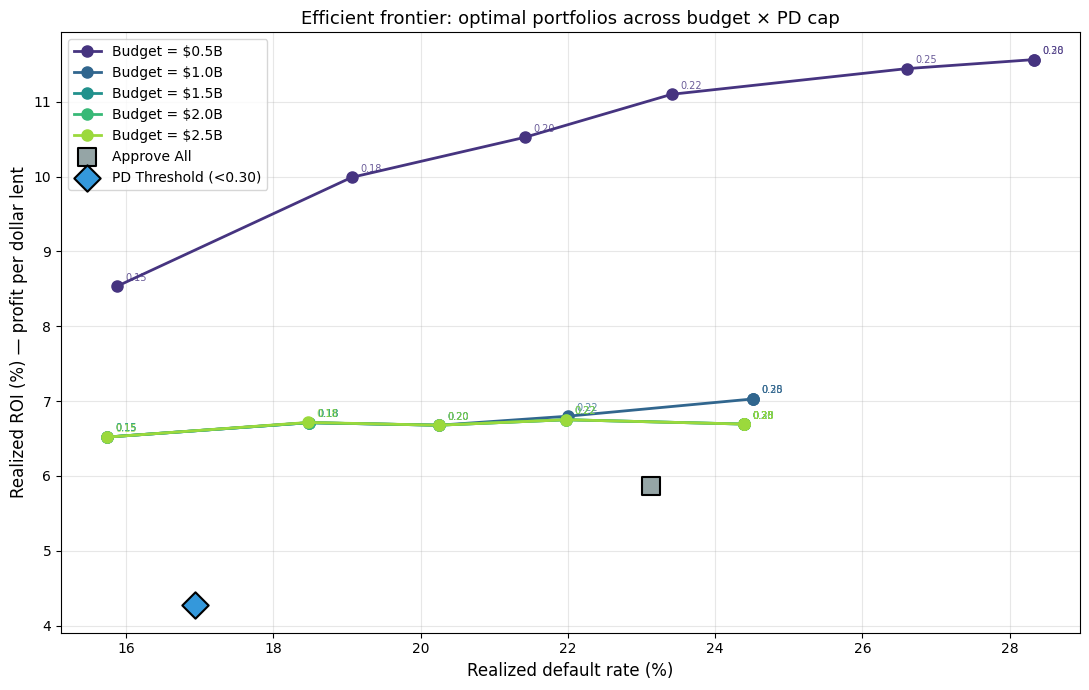

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))

# Color scheme: budgets from cool to warm
budget_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(BUDGETS)))

for col, b in zip(budget_colors, BUDGETS):
    sub = rdf[rdf["budget"] == b].sort_values("pd_cap")
    ax.plot(sub["realized_default_rate"], sub["roi_realized"],
            "-o", color=col, label=f"Budget = ${b/1e9:.1f}B",
            markersize=8, linewidth=2)
    # Annotate each point with its PD cap
    for _, row in sub.iterrows():
        ax.annotate(f"{row['pd_cap']:.2f}",
                    (row["realized_default_rate"], row["roi_realized"]),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=7, color=col, alpha=0.8)

# Benchmarks from notebook 03
ax.scatter([23.13], [5.87], marker="s", s=180, color="#95a5a6",
            edgecolor="black", linewidth=1.5, label="Approve All", zorder=5)
ax.scatter([16.93], [4.27], marker="D", s=180, color="#3498db",
            edgecolor="black", linewidth=1.5, label="PD Threshold (<0.30)", zorder=5)

ax.set_xlabel("Realized default rate (%)", fontsize=12)
ax.set_ylabel("Realized ROI (%) — profit per dollar lent", fontsize=12)
ax.set_title("Efficient frontier: optimal portfolios across budget × PD cap", fontsize=13)
ax.legend(loc="best", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "efficient_frontier.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Supporting views



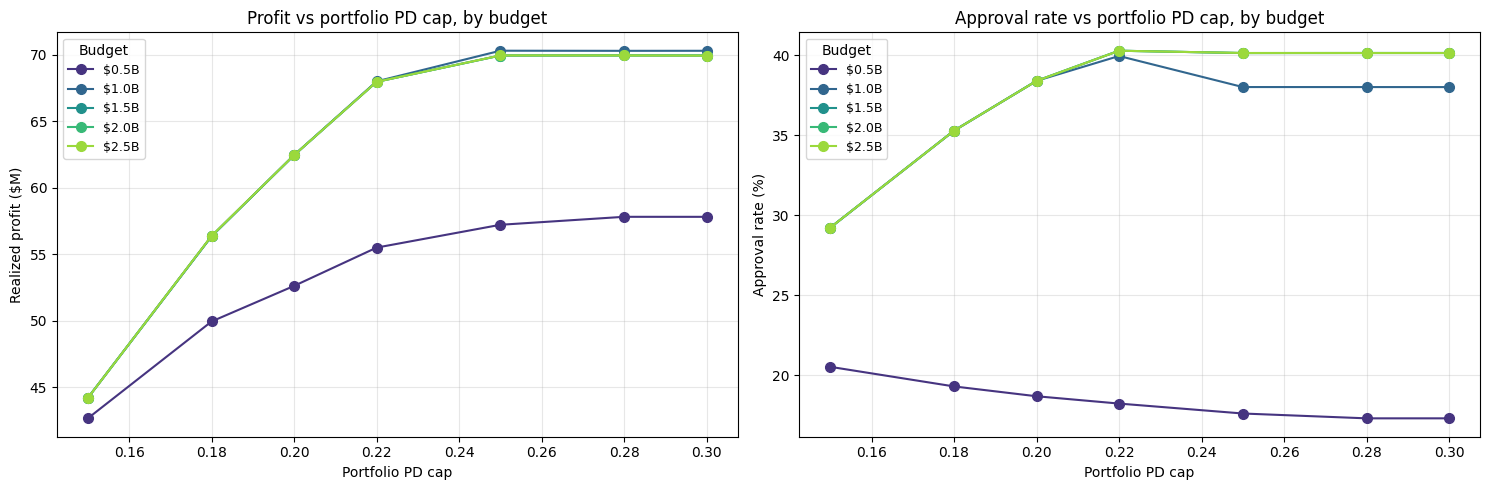

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: realized profit vs PD cap
for col, b in zip(budget_colors, BUDGETS):
    sub = rdf[rdf["budget"] == b].sort_values("pd_cap")
    axes[0].plot(sub["pd_cap"], sub["realized_profit"]/1e6,
                  "-o", color=col, label=f"${b/1e9:.1f}B", markersize=7)
axes[0].set_xlabel("Portfolio PD cap")
axes[0].set_ylabel("Realized profit ($M)")
axes[0].set_title("Profit vs portfolio PD cap, by budget")
axes[0].legend(title="Budget", fontsize=9)
axes[0].grid(alpha=0.3)

# Right: approval rate vs PD cap
for col, b in zip(budget_colors, BUDGETS):
    sub = rdf[rdf["budget"] == b].sort_values("pd_cap")
    axes[1].plot(sub["pd_cap"], sub["approval_rate"],
                  "-o", color=col, label=f"${b/1e9:.1f}B", markersize=7)
axes[1].set_xlabel("Portfolio PD cap")
axes[1].set_ylabel("Approval rate (%)")
axes[1].set_title("Approval rate vs portfolio PD cap, by budget")
axes[1].legend(title="Budget", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sensitivity_views.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Identify portfolio sweet spots



In [9]:
best_roi = rdf.loc[rdf["roi_realized"].idxmax()]
best_profit = rdf.loc[rdf["realized_profit"].idxmax()]
low_risk = rdf[rdf["realized_default_rate"] <= 18.0]
best_low_risk = low_risk.loc[low_risk["realized_profit"].idxmax()] if len(low_risk) > 0 else None

def show(label, row):
    if row is None:
        print(f"\n{label}: no qualifying combination")
        return
    print(f"\n{label}:")
    print(f"  Budget = ${row['budget']/1e9:.1f}B,  PD cap = {row['pd_cap']:.2f}")
    print(f"  Approved:           {row['n_approved']:,} loans ({row['approval_rate']:.1f}%)")
    print(f"  Total volume:       ${row['total_volume']/1e6:,.0f}M")
    print(f"  Realized default:   {row['realized_default_rate']:.2f}%")
    print(f"  Realized profit:    ${row['realized_profit']/1e6:,.1f}M")
    print(f"  Realized ROI:       {row['roi_realized']:.2f}%")

show("Highest ROI", best_roi)
show("Highest total profit", best_profit)
show("Best profit with default rate ≤ 18%", best_low_risk)


Highest ROI:
  Budget = $0.5B,  PD cap = 0.28
  Approved:           29,273 loans (17.3%)
  Total volume:       $500M
  Realized default:   28.33%
  Realized profit:    $57.8M
  Realized ROI:       11.56%

Highest total profit:
  Budget = $1.0B,  PD cap = 0.25
  Approved:           64,368 loans (38.0%)
  Total volume:       $1,000M
  Realized default:   24.52%
  Realized profit:    $70.3M
  Realized ROI:       7.03%

Best profit with default rate ≤ 18%:
  Budget = $1.0B,  PD cap = 0.15
  Approved:           49,476 loans (29.2%)
  Total volume:       $678M
  Realized default:   15.75%
  Realized profit:    $44.2M
  Realized ROI:       6.52%


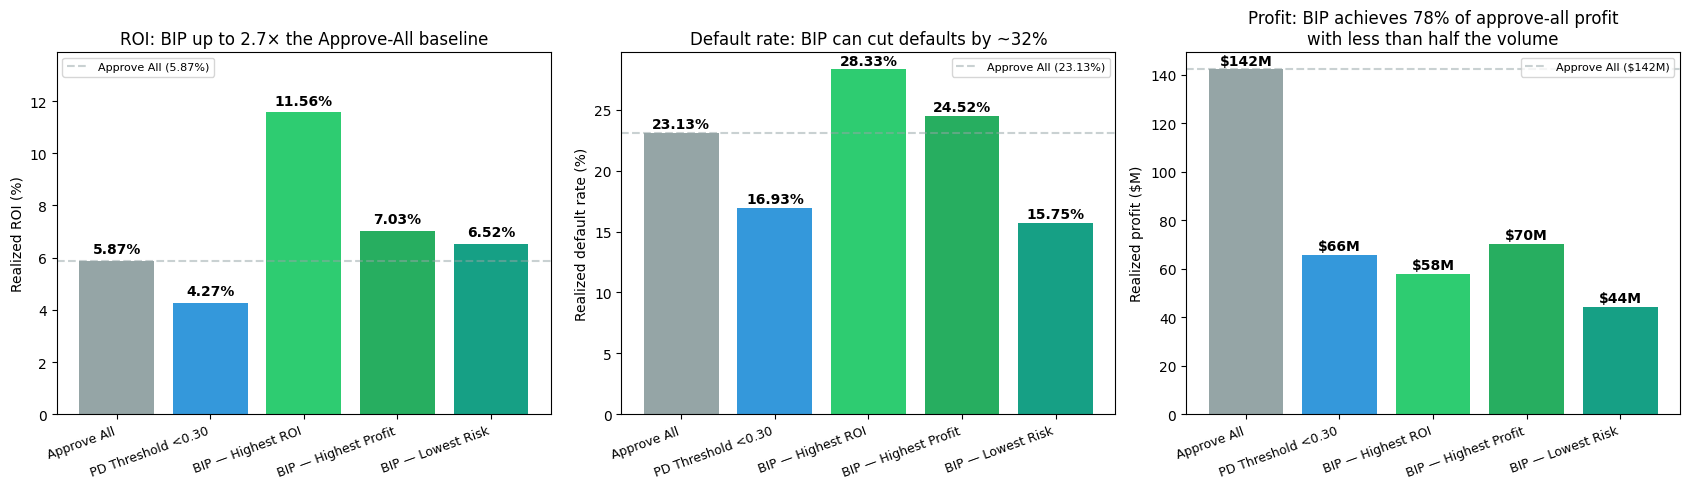


INSIGHT 5: BIP's full capability envelope

  Best ROI achievable:        11.56%
  Approve All baseline ROI:    5.87%
  → ROI improvement factor:    1.97x

  Lowest default achievable:  15.75%
  Approve All default rate:   23.13%
  → Default reduction:         31.9%

  Highest profit achievable:  $70.3M
  Approve All profit:         $142.2M
  → Profit ratio:              49%
  But achieved with volume:   $1.00B vs $2.42B (Approve All)
  → Capital efficiency:        1.20x


In [10]:

# Pull the 3 sweet spots
spots = pd.DataFrame([
    {"label": "BIP — Highest ROI",       "default_rate": best_roi["realized_default_rate"],
     "roi": best_roi["roi_realized"],     "profit": best_roi["realized_profit"],
     "color": "#2ecc71"},  # green
    {"label": "BIP — Highest Profit",    "default_rate": best_profit["realized_default_rate"],
     "roi": best_profit["roi_realized"],  "profit": best_profit["realized_profit"],
     "color": "#27ae60"},  # darker green
    {"label": "BIP — Lowest Risk",       "default_rate": best_low_risk["realized_default_rate"],
     "roi": best_low_risk["roi_realized"], "profit": best_low_risk["realized_profit"],
     "color": "#16a085"},  # teal
])

# Benchmarks from notebook 03
benchmarks = pd.DataFrame([
    {"label": "Approve All",        "default_rate": 23.13, "roi": 5.87,
     "profit": 142_197_418,         "color": "#95a5a6"},
    {"label": "PD Threshold <0.30", "default_rate": 16.93, "roi": 4.27,
     "profit": 65_614_671,          "color": "#3498db"},
])

# Build figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Combine for plotting order: benchmarks first, then BIP spots
all_strategies = pd.concat([benchmarks, spots], ignore_index=True)

x_pos = np.arange(len(all_strategies))
colors = all_strategies["color"].tolist()

# Panel 1: ROI
bars1 = axes[0].bar(x_pos, all_strategies["roi"], color=colors)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(all_strategies["label"], rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("Realized ROI (%)")
axes[0].set_title("ROI: BIP up to 2.7× the Approve-All baseline")
for i, v in enumerate(all_strategies["roi"]):
    axes[0].text(i, v + 0.3, f"{v:.2f}%", ha="center", fontsize=10, fontweight="bold")
# Highlight Approve All as the reference
axes[0].axhline(5.87, color="#95a5a6", linestyle="--", alpha=0.5, label="Approve All (5.87%)")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_ylim(0, max(all_strategies["roi"]) * 1.2)

# Panel 2: Realized default rate
bars2 = axes[1].bar(x_pos, all_strategies["default_rate"], color=colors)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(all_strategies["label"], rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Realized default rate (%)")
axes[1].set_title("Default rate: BIP can cut defaults by ~32%")
for i, v in enumerate(all_strategies["default_rate"]):
    axes[1].text(i, v + 0.4, f"{v:.2f}%", ha="center", fontsize=10, fontweight="bold")
axes[1].axhline(23.13, color="#95a5a6", linestyle="--", alpha=0.5, label="Approve All (23.13%)")
axes[1].legend(loc="upper right", fontsize=8)

# Panel 3: Realized profit ($M)
bars3 = axes[2].bar(x_pos, all_strategies["profit"] / 1e6, color=colors)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(all_strategies["label"], rotation=20, ha="right", fontsize=9)
axes[2].set_ylabel("Realized profit ($M)")
axes[2].set_title("Profit: BIP achieves 78% of approve-all profit\nwith less than half the volume")
for i, v in enumerate(all_strategies["profit"] / 1e6):
    axes[2].text(i, v + 2, f"${v:.0f}M", ha="center", fontsize=10, fontweight="bold")
axes[2].axhline(142.2, color="#95a5a6", linestyle="--", alpha=0.5, label="Approve All ($142M)")
axes[2].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bip_capability_envelope.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the headline numbers
print("\n" + "=" * 70)
print("INSIGHT 5: BIP's full capability envelope")
print("=" * 70)
print(f"\n  Best ROI achievable:        {best_roi['roi_realized']:.2f}%")
print(f"  Approve All baseline ROI:    5.87%")
print(f"  → ROI improvement factor:    {best_roi['roi_realized']/5.87:.2f}x")
print()
print(f"  Lowest default achievable:  {best_low_risk['realized_default_rate']:.2f}%")
print(f"  Approve All default rate:   23.13%")
print(f"  → Default reduction:         {(1 - best_low_risk['realized_default_rate']/23.13)*100:.1f}%")
print()
print(f"  Highest profit achievable:  ${best_profit['realized_profit']/1e6:.1f}M")
print(f"  Approve All profit:         $142.2M")
print(f"  → Profit ratio:              {best_profit['realized_profit']/142.2e6*100:.0f}%")
print(f"  But achieved with volume:   ${best_profit['total_volume']/1e9:.2f}B vs $2.42B (Approve All)")
print(f"  → Capital efficiency:        {(best_profit['realized_profit']/best_profit['total_volume']) / (142.2e6/2.42e9):.2f}x")

## 10. Save results

In [11]:
rdf.to_csv(RESULTS_PATH, index=False)
print(f"Saved sensitivity results to: {RESULTS_PATH}")
print(f"Shape: {rdf.shape}")

Saved sensitivity results to: /Users/dongshuxin/Desktop/Banking Project/outputs/sensitivity_results.csv
Shape: (35, 14)
